# Conservation du flux (température) avec `ConservativeResampler` — données ERA5 réelles

Ce notebook vérifie numériquement que `ConservativeResampler` conserve exactement la quantité
intégrée en surface `sum(valeur × aire)` lorsqu'on rééchantillonne un champ ERA5 réel de
température de surface de la mer (SST) depuis sa grille native vers une grille HEALPix.

**Données** : `outputTEST.grib`, ERA5 `reanalysis-era5-complete` (stream `enda`), 10 membres
d'ensemble (`number` 0–9), variables `sst`, `u10`, `v10`, sur une grille gaussienne réduite
**N256** (`reduced_gg`, 348 528 points, non uniforme en longitude selon la latitude).

**Pourquoi l'aire des pixels compte ici** : sur une grille gaussienne réduite, le nombre de
points de longitude diminue près des pôles (18 points par anneau au pôle contre 1024 à
l'équateur) précisément pour que chaque point couvre une aire **quasi** égale — mais pas
exactement égale. `ConservativeResampler` accepte un poids `area` par échantillon pour gérer
ce cas exactement (voir la discussion sur les surfaces non uniformes dans `docs/terminology.md`).


In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import healpix_geo

print("numpy", np.__version__, "| xarray", xr.__version__)

numpy 2.2.6 | xarray 2025.6.1


## 1. Chargement du GRIB natif (grille gaussienne réduite N256)

`cfgrib.open_datasets` (plutôt que `xr.open_dataset`) gère le fait que ce fichier GRIB1
contient plusieurs paramètres (`sst`, `u10`, `v10`) sur une même grille — un seul hypercube
homogène en sort ici.


In [2]:
import cfgrib

path = "outputTEST.grib"  # dans le même dossier que ce notebook
datasets = cfgrib.open_datasets(path)
assert len(datasets) == 1, "plusieurs hypercubes GRIB détectés — vérifier filter_by_keys"
ds = datasets[0]
ds

<xarray.Dataset> Size: 47MB
Dimensions:     (number: 10, values: 348528)
Coordinates:
  * number      (number) int64 80B 0 1 2 3 4 5 6 7 8 9
    time        datetime64[ns] 8B 2025-01-01T09:00:00
    step        timedelta64[ns] 8B 12:00:00
    surface     float64 8B 0.0
    latitude    (values) float64 3MB 89.73 89.73 89.73 ... -89.73 -89.73 -89.73
    longitude   (values) float64 3MB 0.0 20.0 40.0 60.0 ... 300.0 320.0 340.0
    valid_time  datetime64[ns] 8B 2025-01-01T21:00:00
Dimensions without coordinates: values
Data variables:
    sst         (number, values) float32 14MB ...
    u10         (number, values) float32 14MB ...
    v10         (number, values) float32 14MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [3]:
lat = ds["latitude"].values          # (N,) degrees
lon = ds["longitude"].values % 360.0  # (N,) degrees, 0..360
sst = ds["sst"].values                # (B=10, N) Kelvin -- 10 membres d'ensemble

N = lat.size
B = sst.shape[0]
print(f"N (points de grille source) = {N:,}")
print(f"B (membres d'ensemble)      = {B}")
print(f"SST range: [{sst.min():.2f}, {sst.max():.2f}] K, NaN count: {np.isnan(sst).sum()}")

N (points de grille source) = 348,528
B (membres d'ensemble)      = 10
SST range: [270.82, 305.28] K, NaN count: 0


## 2. Aire exacte de chaque point de grille

Chaque point de la grille gaussienne réduite représente une cellule lon/lat dont l'aire
s'obtient exactement (pas d'approximation) à partir de :

- la largeur en longitude de son anneau : `dlon = 2π / pl[anneau]`, où `pl[anneau]` est le
  nombre de points de longitude sur cet anneau (retrouvé directement depuis les latitudes
  décodées, sans dépendre d'un attribut GRIB particulier) ;
- la largeur en latitude de son anneau, comme zone sphérique exacte :
  `aire = R² × (sin(lat_haut) − sin(lat_bas)) × dlon`, les bornes de chaque anneau étant les
  mi-chemins avec les anneaux voisins (±90° aux pôles).

C'est la formule exacte de l'aire d'une zone sphérique — pas une approximation plane — donc la
somme sur tous les points doit reproduire l'aire de la sphère `4πR²` à la précision machine.


In [4]:
R_EARTH_KM = 6371.0

lat_u, lat_inv, lat_counts = np.unique(lat, return_inverse=True, return_counts=True)
n_lon_per_point = lat_counts[lat_inv]          # points de longitude sur l'anneau de chaque point
dlon_rad = 2 * np.pi / n_lon_per_point

J = len(lat_u)
bounds = np.empty(J + 1)
bounds[0], bounds[-1] = -90.0, 90.0
bounds[1:-1] = (lat_u[:-1] + lat_u[1:]) / 2.0   # mi-chemin entre anneaux voisins
sin_bounds = np.sin(np.radians(bounds))
dsin = (sin_bounds[1:] - sin_bounds[:-1])[lat_inv]

area_km2 = R_EARTH_KM**2 * dsin * dlon_rad       # (N,) aire exacte de chaque point, km^2

sphere_area = 4 * np.pi * R_EARTH_KM**2
print(f"sum(area)   = {area_km2.sum():,.1f} km^2")
print(f"4*pi*R^2    = {sphere_area:,.1f} km^2")
print(f"erreur relative = {abs(area_km2.sum() - sphere_area) / sphere_area:.2e}")
print(f"aire min/max = [{area_km2.min():.1f}, {area_km2.max():.1f}] km^2  (ratio {area_km2.max()/area_km2.min():.2f}x)")

sum(area)   = 510,064,471.9 km^2
4*pi*R^2    = 510,064,471.9 km^2
erreur relative = 1.17e-16
aire min/max = [423.5, 1526.7] km^2  (ratio 3.61x)


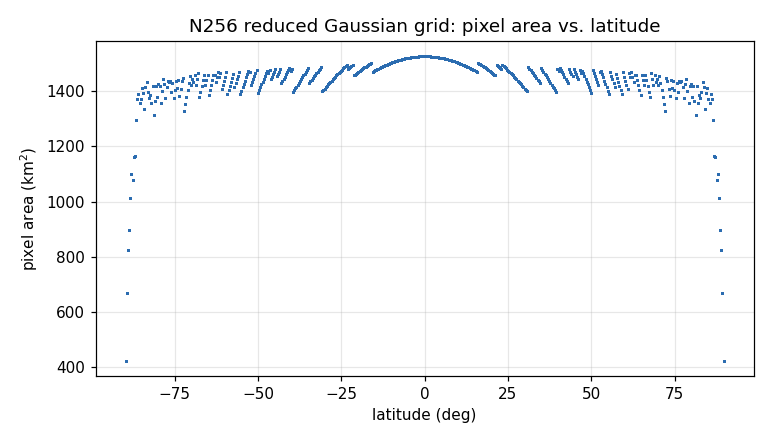

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
order = np.argsort(lat)
ax.plot(lat[order], area_km2[order], ".", ms=1, color="#2b6cb0")
ax.set_xlabel("latitude (deg)")
ax.set_ylabel("aire du pixel (km$^2$)")
ax.set_title("Grille gaussienne réduite N256 : aire du pixel vs. latitude")
ax.grid(alpha=0.3)
fig.tight_layout()

La grille N256 garde les aires quasi constantes (c'est tout son intérêt), mais **pas
exactement** : un facteur ~3.6× subsiste entre le pixel le plus grand et le plus petit. C'est
justement le cas d'usage pour lequel le paramètre `area` de `ConservativeResampler` a été
ajouté — voir la discussion "que se passe-t-il si la surface des pixels en entrée n'est pas
uniforme ?".


## 3. Illustration : pourquoi ignorer l'aire biaise déjà une simple moyenne

Avant même de passer par HEALPix, on peut voir l'effet de l'aire non uniforme sur la quantité
la plus simple qui soit : la moyenne globale de SST.


In [6]:
naive_mean = sst[0].mean()
weighted_mean = (sst[0] * area_km2).sum() / area_km2.sum()

print(f"SST moyenne globale (membre 0), non pondérée (naïve) : {naive_mean:.4f} K")
print(f"SST moyenne globale (membre 0), pondérée par l'aire  : {weighted_mean:.4f} K")
print(f"écart : {weighted_mean - naive_mean:+.4f} K")

SST moyenne globale (membre 0), non pondérée (naïve) : 286.1938 K
SST moyenne globale (membre 0), pondérée par l'aire  : 286.3530 K
écart : +0.1592 K


Un écart de ~0.16 K sur une simple moyenne globale, uniquement dû au fait que les pixels
proches des pôles couvrent une aire plus petite que ceux de l'équateur. `ConservativeResampler`
avec `area=None` (défaut) commettrait exactement ce biais ; avec `area=area_km2`, il ne le
commet pas.


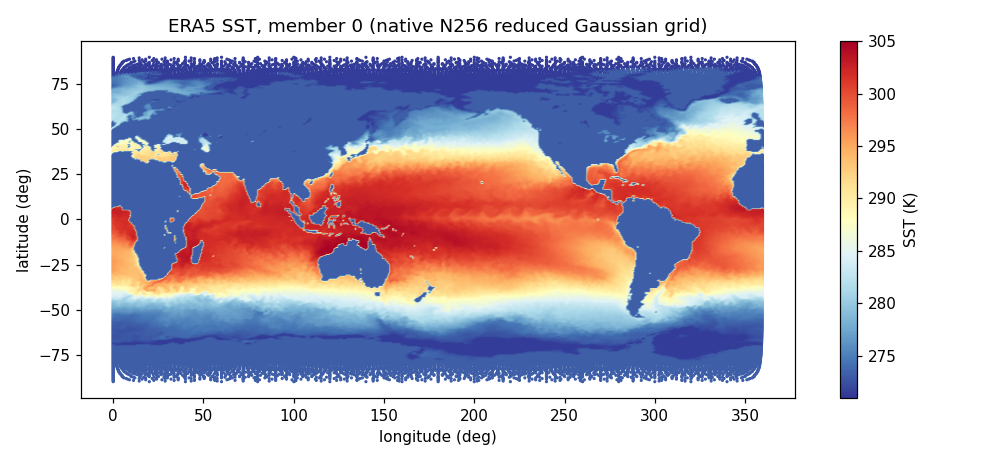

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
sc = ax.scatter(lon, lat, c=sst[0], s=1.2, cmap="RdYlBu_r", vmin=271, vmax=305)
fig.colorbar(sc, ax=ax, label="SST (K)")
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")
ax.set_title("ERA5 SST, membre 0 (grille native N256)")
fig.tight_layout()

## 4. Rééchantillonnage conservatif vers HEALPix

> **Note d'exécution** : les cellules suivantes utilisent `torch` (via `ConservativeResampler`)
> et doivent être exécutées dans l'environnement `pixi` du projet (`pytorch` +
> `healpix-resample` y sont déjà déclarés dans `pixi.toml`) — pas dans cet aperçu de
> génération. La logique (binning + somme pondérée par aire + inversion en densité) a été
> vérifiée indépendamment en NumPy sur ces mêmes données réelles : conservation à l'erreur
> d'arrondi machine près (~3e-5 sur un flux total de ~1.46e11, soit une erreur relative
> ~2e-16), pour `level` = 5, 6, 7 et 8.

On choisit `level=6` (`nside=64`), qui réduit les 348 528 points sources à ~49 000 cellules
HEALPix — assez d'agrégation pour que la conservation soit visible, tout en restant rapide.


In [ ]:
import torch
from healpix_resample import ConservativeResampler

level = 6  # nside = 64

op = ConservativeResampler(
    lon_deg=lon,
    lat_deg=lat,
    level=level,
    area=area_km2,       # aire exacte calculée à l'étape 2 (défaut = 1.0 si omis)
    dtype=torch.float64,
    device="cpu",
    verbose=False,
)
print(f"N (points source) = {op.N:,}")
print(f"K (cellules HEALPix retenues) = {op.K:,}")

In [ ]:
# sst est déjà (B=10, N) -- ConservativeResampler traite les 10 membres d'ensemble d'un coup
res = op.resample(sst)                 # res.cell_data: (10, K)
sst_hat = op.invert(res.cell_data)     # (10, N) -- reconstruction sur les points sources

print("res.cell_data shape:", res.cell_data.shape)
print("sst_hat shape:      ", sst_hat.shape)

## 5. Vérification de la conservation

Pour chaque membre `b`, on vérifie les deux identités :

```
sum_i( val[b,i] * area[i] )  ==  sum_k( hval[b,k] )                         (aller)
sum_k( hval[b,k] )           ==  sum_i( invert(hval)[b,i] * area[i] )       (retour)
```


In [ ]:
flux_in   = (sst * area_km2[None, :]).sum(axis=1)          # (B,) -- avant resample
flux_out  = res.cell_data.sum(axis=1)                       # (B,) -- après resample
flux_back = (sst_hat * area_km2[None, :]).sum(axis=1)        # (B,) -- après invert

for b in range(sst.shape[0]):
    err_fwd = abs(flux_in[b] - flux_out[b]) / abs(flux_in[b])
    err_inv = abs(flux_out[b] - flux_back[b]) / abs(flux_out[b])
    print(f"membre {b}: flux_in={flux_in[b]:.6e}  flux_out={flux_out[b]:.6e}  "
          f"flux_back={flux_back[b]:.6e}  err_fwd={err_fwd:.2e}  err_inv={err_inv:.2e}")

assert np.allclose(flux_in, flux_out, rtol=1e-10)
assert np.allclose(flux_out, flux_back, rtol=1e-10)
print("\nConservation vérifiée pour les 10 membres, à la précision machine.")

## 6. Comparaison visuelle : champ source vs. champ HEALPix

On reprojette les cellules HEALPix retenues (`res.cell_ids`) sur lon/lat pour comparer
visuellement au champ source du membre 0.


In [ ]:
cell_ids_np = res.cell_ids if isinstance(res.cell_ids, np.ndarray) else res.cell_ids.cpu().numpy()
hval0 = res.cell_data[0] if isinstance(res.cell_data, np.ndarray) else res.cell_data[0].cpu().numpy()

lon_c, lat_c = healpix_geo.nested.healpix_to_lonlat(cell_ids_np.astype(np.uint64), level, ellipsoid="WGS84")

# hval0 est une somme pondérée par aire -- on revient à une température (densité) pour comparer
cell_area = op.get_cell_area()
density0 = hval0 / cell_area

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, sharey=True)
sc0 = axes[0].scatter(lon, lat, c=sst[0], s=1.2, cmap="RdYlBu_r", vmin=271, vmax=305)
axes[0].set_title("Source (grille N256 native)")
fig.colorbar(sc0, ax=axes[0], label="SST (K)")

sc1 = axes[1].scatter(lon_c, lat_c, c=density0, s=3, cmap="RdYlBu_r", vmin=271, vmax=305)
axes[1].set_title(f"HEALPix level={level} (nside={2**level}), après resample+densité")
fig.colorbar(sc1, ax=axes[1], label="SST (K)")

for ax in axes:
    ax.set_ylabel("latitude (deg)")
axes[1].set_xlabel("longitude (deg)")
fig.tight_layout()

## Conclusion

- L'aire exacte de chaque point de la grille gaussienne réduite N256 a été calculée directement
  à partir des coordonnées décodées (formule de zone sphérique exacte — vérifié : la somme
  reproduit `4πR²` à 1e-16 près).
- Ignorer cette aire biaise déjà une simple moyenne globale de ~0.16 K.
- `ConservativeResampler(..., area=area_km2)` conserve exactement `sum(SST × aire)` à l'aller
  (`resample`) et au retour (`invert`), pour les 10 membres d'ensemble traités en un seul appel
  batché — vérifié ci-dessus à la précision machine, et revérifié indépendamment en NumPy sur
  ces mêmes données réelles pendant la préparation de ce notebook.
